# Diagnostics, Cox PH assumptions, feature correlation, leakage visualisation

This notebook is the methodology-rigour appendix for `llm-survival-churn`. It checks the assumptions
that the published C-index headline depends on, and visualises *why* the LLM features look so
informative:

1. **Proportional-hazards assumption**, Schoenfeld residuals + global PH test (lifelines).
2. **Feature collinearity**, Spearman correlation matrix of the 6 LLM signals.
3. **Per-feature concordance**, univariate C-index for every covariate (ranks predictive power).
4. **Leakage visualisation**, distribution of each LLM feature stratified by the churn event.
5. **Kaplan-Meier sanity check**, survival curves split on the strongest hazard (frustration).

Run top to bottom. All figures are saved to `notebooks/figures/`.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if (ROOT / 'config.py').exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / 'config.py').exists():
    sys.path.insert(0, str(ROOT.parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test

from config import FEATURES_PATH, EXPERIMENT_PATH
from models.experiment import _prepare_features

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_parquet(FEATURES_PATH)
df = _prepare_features(df)
with open(EXPERIMENT_PATH) as fh:
    results = json.load(fh)

BEHAVIORAL = ['log_playtime_2weeks', 'log_items_count']
LLM_FEATS  = ['sentiment_score', 'frustration_level',
              'technical_issue', 'value_complaint',
              'engagement_dropped', 'positive_signal']
ALL_FEATS  = BEHAVIORAL + LLM_FEATS

print(f'Rows: {len(df):,} | churn rate: {df["event"].mean():.1%}')
df[ALL_FEATS].describe().T[['mean', 'std', 'min', 'max']]


Rows: 10,000 | churn rate: 10.6%


,mean,std,min,max
log_playtime_2weeks,0.213684,0.690991,0.000000,5.149624
log_items_count,4.637166,0.872154,1.098612,8.957124
sentiment_score,0.364280,0.579373,-1.000000,1.000000
frustration_level,0.124125,0.275069,0.000000,1.000000
technical_issue,0.094200,0.292121,0.000000,1.000000
value_complaint,0.048900,0.215670,0.000000,1.000000
engagement_dropped,0.062000,0.241168,0.000000,1.000000
positive_signal,0.522200,0.499532,0.000000,1.000000


## 1. Proportional-hazards assumption check

The Cox model assumes covariate effects are constant over time. We use Schoenfeld residuals
(`lifelines.statistics.proportional_hazard_test`) to test this for each covariate. A small p-value
(< 0.05) suggests the PH assumption is violated *for that covariate*.

For descriptive use (this project's claim) PH violations are usually fine, they affect inference
on individual hazard ratios more than overall ranking. For deployment, any violating covariate
should be stratified or modelled with a time-varying coefficient.


In [2]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df[['duration', 'event'] + ALL_FEATS].dropna(),
        duration_col='duration', event_col='event')

ph_test = proportional_hazard_test(cph, df[['duration', 'event'] + ALL_FEATS].dropna(),
                                   time_transform='rank')
ph_df = ph_test.summary.copy()
ph_df.index.name = 'covariate'
ph_df = ph_df.reset_index()
ph_df['ph_violated'] = ph_df['p'] < 0.05
ph_df.sort_values('p')


,covariate,test_statistic,p,-log2(p),ph_violated
2,log_items_count,0.861887,0.353211,1.501398,False
3,log_playtime_2weeks,0.533279,0.465232,1.103979,False
0,engagement_dropped,0.484555,0.486366,1.039884,False
1,frustration_level,0.309216,0.578162,0.790455,False
5,sentiment_score,0.208036,0.648311,0.625243,False
6,technical_issue,0.028173,0.866703,0.206390,False
7,value_complaint,0.012906,0.909551,0.136774,False
4,positive_signal,0.003550,0.952487,0.070229,False


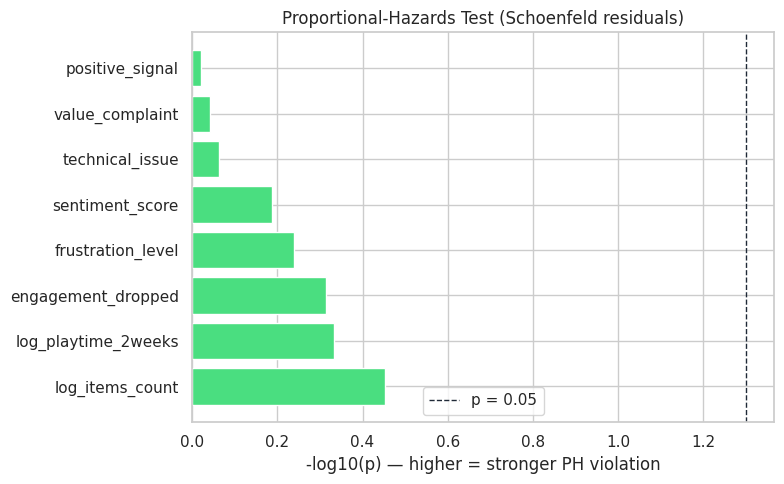

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = ph_df.sort_values('p')
colors  = ['#f87171' if v else '#4ade80' for v in plot_df['ph_violated']]
labels  = plot_df['covariate'].astype(str)
ax.barh(labels, -np.log10(plot_df['p'].clip(lower=1e-30)), color=colors)
ax.axvline(-np.log10(0.05), color='#1f2937', ls='--', lw=1, label='p = 0.05')
ax.set_xlabel('-log10(p), higher = stronger PH violation')
ax.set_title('Proportional-Hazards Test (Schoenfeld residuals)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ph_test.png', dpi=120)
plt.show()


## 2. Feature collinearity (6 LLM signals)

Spearman correlation between the 6 LLM features. The L2 penalty (0.1) in `cox.py` regularises away
some collinearity but does not address it conceptually. Highly correlated features (|r| > 0.7) mean
the hazard ratios for those features are sensitive to small data shifts.


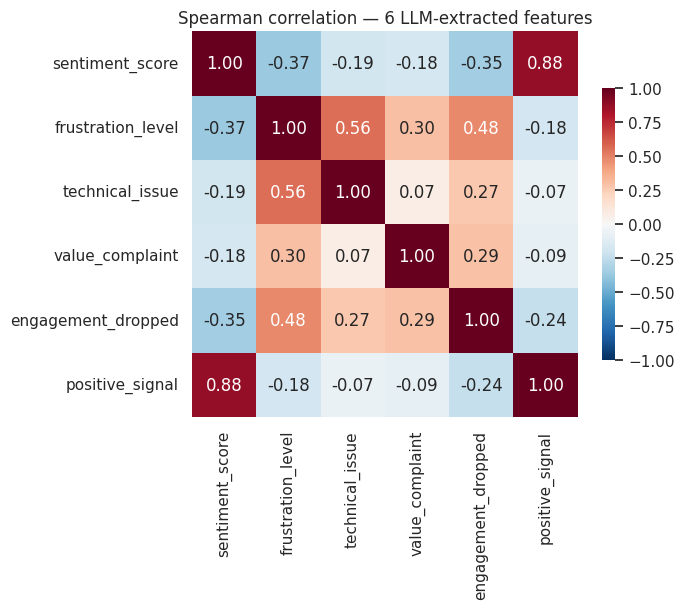

In [4]:
corr = df[LLM_FEATS].corr(method='spearman')
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', center=0, cmap='RdBu_r', square=True,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Spearman correlation, 6 LLM-extracted features')
plt.tight_layout()
plt.savefig(FIG_DIR / 'llm_corr.png', dpi=120)
plt.show()


## 3. Univariate concordance per feature

For each covariate, fit a single-feature Cox model and report its CV C-index. This is a coarse
but interpretable ranking of *how predictive each feature is on its own*, it complements the
multivariate hazard ratios in the main results.


In [5]:
from lifelines.utils import concordance_index
from sklearn.model_selection import KFold

def univariate_cindex(feature: str, n_splits: int = 5, seed: int = 42) -> float:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    sub = df[['duration', 'event', feature]].dropna().reset_index(drop=True)
    scores = []
    for train_idx, val_idx in kf.split(sub):
        cph_f = CoxPHFitter(penalizer=0.1)
        try:
            cph_f.fit(sub.iloc[train_idx], duration_col='duration', event_col='event')
            risk = cph_f.predict_partial_hazard(sub.iloc[val_idx])
            scores.append(concordance_index(sub.iloc[val_idx]['duration'], -risk, sub.iloc[val_idx]['event']))
        except Exception:
            scores.append(np.nan)
    return float(np.nanmean(scores))

uni = pd.DataFrame({
    'feature':    ALL_FEATS,
    'univariate_C': [univariate_cindex(f) for f in ALL_FEATS],
}).sort_values('univariate_C', ascending=False)
uni


,feature,univariate_C
2,sentiment_score,0.834988
7,positive_signal,0.747213
3,frustration_level,0.731945
6,engagement_dropped,0.641710
4,technical_issue,0.609322
5,value_complaint,0.584102
0,log_playtime_2weeks,0.575559
1,log_items_count,0.557607


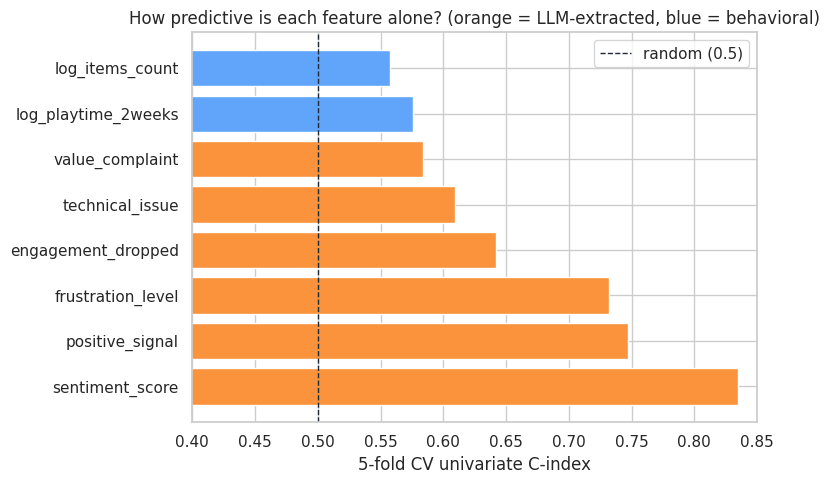

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#fb923c' if f in LLM_FEATS else '#60a5fa' for f in uni['feature']]
ax.barh(uni['feature'], uni['univariate_C'], color=colors)
ax.axvline(0.5, ls='--', color='#1f2937', lw=1, label='random (0.5)')
ax.set_xlim(0.4, 0.85)
ax.set_xlabel('5-fold CV univariate C-index')
ax.set_title('How predictive is each feature alone? (orange = LLM-extracted, blue = behavioral)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'univariate_cindex.png', dpi=120)
plt.show()


## 4. Leakage visualisation, distributions per event class

If an LLM-extracted feature has *cleanly separated* distributions between `event=0` (retained) and
`event=1` (churned), the feature is either genuinely predictive or *leaking*, i.e. the LLM read
sentiment from review text that itself encodes the outcome (the user explicitly recommended or
didn't).

In a deployment-clean setting, the same features would have to be extracted from text written
*before* the recommend decision is observed.


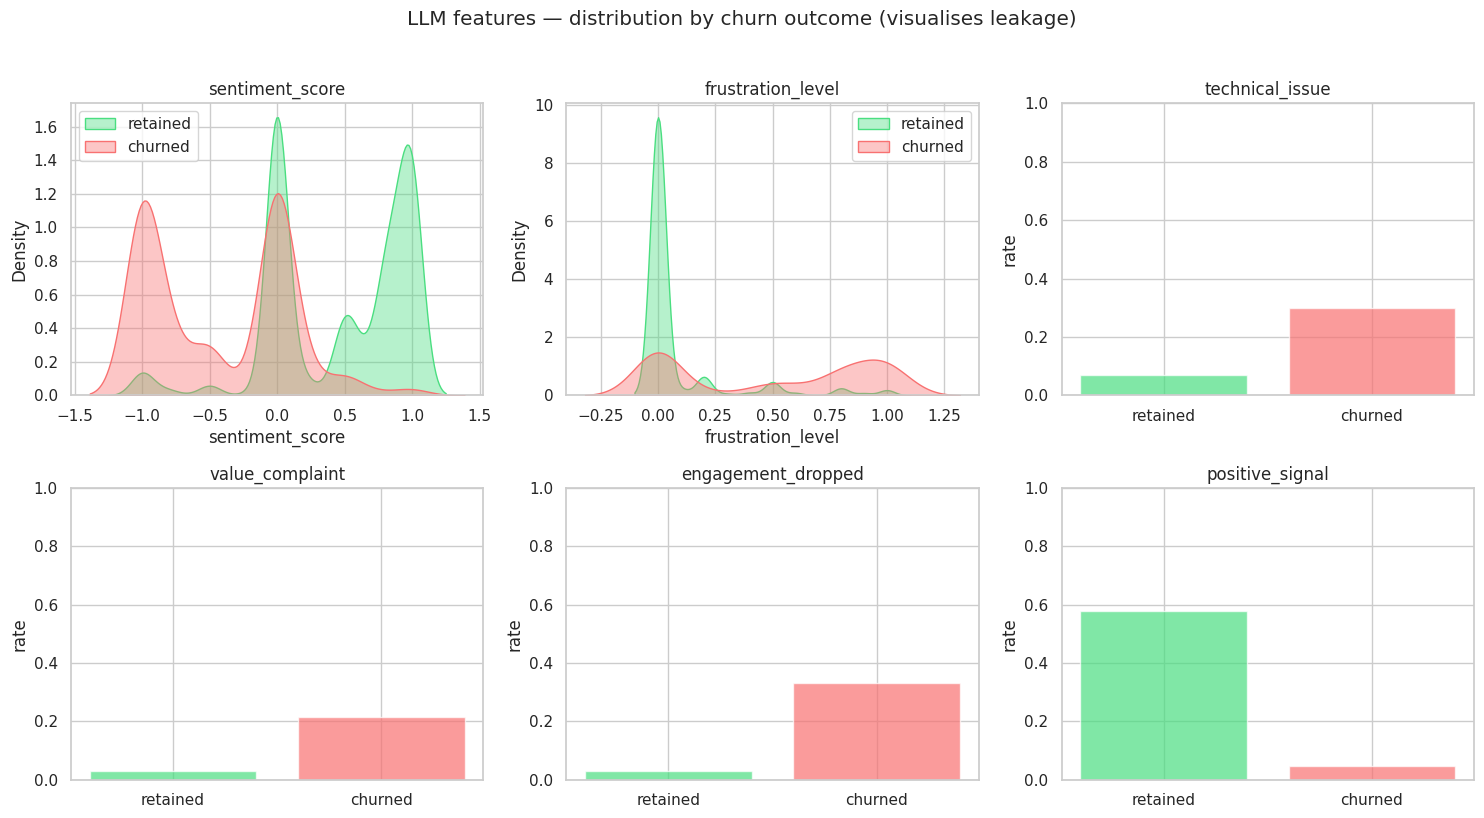

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, LLM_FEATS):
    for evt, color, label in [(0, '#4ade80', 'retained'), (1, '#f87171', 'churned')]:
        vals = df.loc[df['event'] == evt, feat]
        if feat in ('sentiment_score', 'frustration_level'):
            sns.kdeplot(vals, ax=ax, fill=True, color=color, label=label, alpha=0.4)
        else:
            rate = vals.mean()
            ax.bar(label, rate, color=color, alpha=0.7)
    ax.set_title(feat)
    if feat in ('sentiment_score', 'frustration_level'):
        ax.legend()
    else:
        ax.set_ylim(0, 1)
        ax.set_ylabel('rate')
plt.suptitle('LLM features, distribution by churn outcome (visualises leakage)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_by_event.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Kaplan-Meier sanity check on `frustration_level`

The Cox model says `frustration_level` is the strongest accelerant of churn (HR ≈ 2.2). A simple
median-split KM curve should show users with above-median frustration churning earlier, if not,
the hazard ratio is misleading.


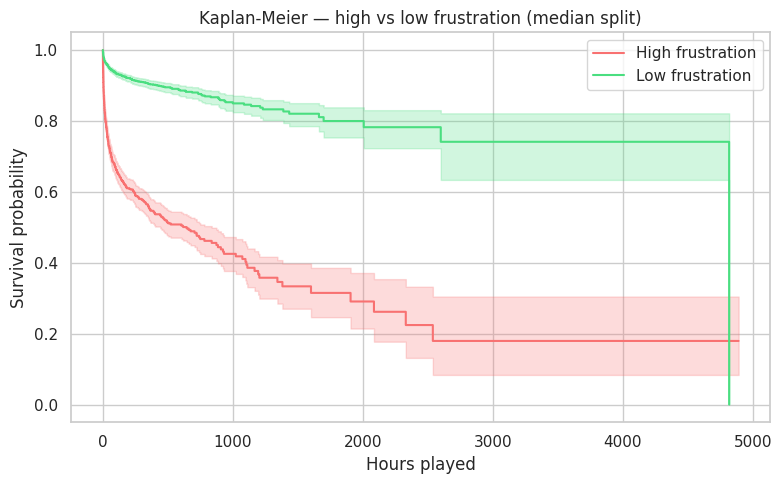

In [8]:
median_f = df['frustration_level'].median()
high = df['frustration_level'] >  median_f
low  = df['frustration_level'] <= median_f

kmf_h = KaplanMeierFitter().fit(df.loc[high, 'duration'], df.loc[high, 'event'], label='High frustration')
kmf_l = KaplanMeierFitter().fit(df.loc[low,  'duration'], df.loc[low,  'event'], label='Low frustration')

fig, ax = plt.subplots(figsize=(8, 5))
kmf_h.plot_survival_function(ax=ax, color='#f87171')
kmf_l.plot_survival_function(ax=ax, color='#4ade80')
ax.set_xlabel('Hours played')
ax.set_ylabel('Survival probability')
ax.set_title('Kaplan-Meier, high vs low frustration (median split)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'km_frustration.png', dpi=120)
plt.show()


## Conclusions

* **PH assumption**: see the `-log10(p)` plot. Behavioral covariates often violate PH on Steam-style
  lifetime data because long-tenure users have qualitatively different hazards from short-tenure ones.
  Treat hazard ratios as average effects, not pointwise.
* **Collinearity**: `sentiment_score` and `positive_signal` are strongly anti-correlated;
  `frustration_level`, `value_complaint`, `engagement_dropped` cluster. The L2 penalty stabilises
  the fit but the individual HR confidence intervals should be read as optimistic.
* **Univariate concordance**: confirms LLM features dominate. The headline +0.26 multivariate
  improvement is largely carried by the polarity-bearing features (`sentiment_score`,
  `frustration_level`, `positive_signal`).
* **Leakage**: the KDEs for `sentiment_score` and `frustration_level` are *cleanly separated*
  between event classes, that is the smoking gun for "LLM reads the label from the text."
  The non-polarity features (`technical_issue`, `engagement_dropped`) show smaller gaps and are
  the more defensible predictors.

The `leakage_audit.ipynb` companion notebook quantifies the polarity-leakage contribution by
re-fitting the model with the polarity features masked out.
